# Education Outcome Prediction — Lighthouse Sanctuary

This notebook predicts whether a resident will **complete** their education program
using only data available early in their stay. It is a **prospective** binary
classifier — features come from the first 3 monthly education records, while the
target reflects the resident's eventual outcome.

---

# 1. Problem Framing

## Business Question

Lighthouse Sanctuary social workers want to know, **early in a resident's stay**,
which residents are on track to complete their education program and which may need
additional academic support.

## Prediction Target

**Binary label per resident:**
- `completed = 1` — resident's last `completion_status` is `"Completed"`
- `completed = 0` — resident's last `completion_status` is `"InProgress"` or `"NotStarted"`

Of the 60 residents, 26 completed (~43%) and 34 are still in-progress (~57%).
Class balance is reasonable; `class_weight='balanced'` is still used for safety.

## Why Prospective?

Features are built exclusively from the **first 3 monthly records** per resident
(the feature window). All other tables (health, counseling, incidents, home visits)
are filtered to dates on or before the resident's 3rd education record date.
The target comes from the resident's **full history** — this temporal split is what
prevents data leakage.

## Success Metrics

- **Primary:** Weighted F1 (classes are roughly balanced)
- **Secondary:** Precision and Recall per class, Confusion Matrix
- **Validation:** 5-fold Stratified CV with `cross_val_predict` (n=60 is too small
  for a holdout set)

## Leakage Prevention

1. **Temporal feature window** — only first 3 education records used as features
2. **SelectFromModel inside sklearn Pipeline** — feature selection is refitted
   inside each CV fold, preventing selection bias
3. **`notes` column excluded** — contains `"Progress: {completion_status}"`, directly
   leaking the target
4. **`enrollment_status` excluded** — always `"Enrolled"`, zero variance

Following the CRISP-DM framework from Chapter 1 of the textbook, this pipeline is classified as a Machine Learning Pipeline (Predictive Analytics) — the primary deliverable is an operational model that flags residents needing academic support, not a report for human analysis. A secondary Logistic Regression model is used for explanation, satisfying the textbook requirement to generate both a causal and predictive model for each pipeline.

---

# 2. Data Loading

In [ ]:
import sys
import os

# Make ml_pipelines/ importable regardless of where Jupyter was launched from.
sys.path.insert(0, os.path.abspath('../..'))

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Windows/Jupyter-safe parallel setting for sklearn in this environment.
N_JOBS = 1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
)

from data.loader import (
    load_residents,
    load_education_records,
    load_health_wellbeing_records,
    load_process_recordings,
    load_intervention_plans,
    load_incident_reports,
    load_home_visitations,
    get_engine,
)
from features.education_features import build_education_features


In [2]:
residents_df    = load_residents()
education_df    = load_education_records()
health_df       = load_health_wellbeing_records()
process_df      = load_process_recordings()
intervention_df = load_intervention_plans()
incident_df     = load_incident_reports()
home_visit_df   = load_home_visitations()

tables = {
    'residents':                residents_df,
    'education_records':        education_df,
    'health_wellbeing_records': health_df,
    'process_recordings':       process_df,
    'intervention_plans':       intervention_df,
    'incident_reports':         incident_df,
    'home_visitations':         home_visit_df,
}
print("\nTable shapes:")
for name, df in tables.items():
    print(f"  {name:<30} {df.shape}")

Loaded 'residents' with 63 rows.
Loaded 'education_records' with 534 rows.
Loaded 'health_wellbeing_records' with 534 rows.
Loaded 'process_recordings' with 2,819 rows.
Loaded 'intervention_plans' with 180 rows.
Loaded 'incident_reports' with 100 rows.
Loaded 'home_visitations' with 1,337 rows.

Table shapes:
  residents                      (63, 49)
  education_records              (534, 10)
  health_wellbeing_records       (534, 14)
  process_recordings             (2819, 16)
  intervention_plans             (180, 11)
  incident_reports               (100, 12)
  home_visitations               (1337, 15)


In [3]:
# Quick sanity checks on education_records
print("completion_status distribution:")
print(education_df["completion_status"].value_counts())
print(f"\nUnique residents in education_records: {education_df['resident_id'].nunique()}")

# Final status per resident (this is the target)
edu_sorted = education_df.sort_values("record_date")
last_status = edu_sorted.groupby("resident_id")["completion_status"].last()
print("\nFinal status distribution per resident:")
print(last_status.value_counts())
print(f"Completed rate: {(last_status == 'Completed').mean():.1%}")

completion_status distribution:
completion_status
InProgress    424
NotStarted     60
Completed      50
Name: count, dtype: int64

Unique residents in education_records: 60

Final status distribution per resident:
completion_status
InProgress    34
Completed     26
Name: count, dtype: int64
Completed rate: 43.3%


---

# 3. Feature Engineering

`build_education_features()` is in `features/education_features.py`. It:

1. Determines a **cutoff date** per resident = date of their 3rd education record
2. Builds education features from records 1–3 only (attendance, progress slopes, etc.)
3. Filters all other tables to records on or before that cutoff
4. One-hot encodes education_level and case_category
5. Drops `notes` (leaks target) and `enrollment_status` (zero variance)
6. Returns a numeric-only DataFrame indexed by `resident_id`

### What build_education_features() Does (Ch. 7)

Per Chapter 7, data preparation must be documented as a reproducible
pipeline, not a black box. Here is exactly what the function does:

**Step 1 — Prospective cutoff date per resident.**
Education records are sorted chronologically per resident and assigned a
row number. Only the first `feature_window_months` (default=3) records
are kept as the feature window. The cutoff date is the maximum
`record_date` among those window records — in practice, the date of the
3rd education record for residents with ≥3 records, or the date of their
last available record if they have fewer. Residents with no education
records are excluded because the target label comes from the last
education record.

**Step 2 — Education features (feature window only).**
From the first 1–3 education records the function computes:
- `early_attendance_mean`: mean of `attendance_rate` over the window
- `early_attendance_slope`: linear slope (scipy linregress) of `attendance_rate` over window records
- `early_progress_mean`: mean of `progress_percent` over the window
- `early_progress_slope`: linear slope of `progress_percent` over window records
- `early_progress_max`: maximum `progress_percent` in the window
- `initial_progress`: `progress_percent` of the chronologically first window record
- `education_level_mode`: mode of `education_level` in the window, then
  one-hot encoded into `ed_level_primary`, `ed_level_secondary`,
  `ed_level_vocational`, `ed_level_collegeprep`

**Step 3 — Cross-table features (filtered to cutoff date).**
Every non-education table is filtered to records on or before the
resident’s cutoff date before aggregating:
- **Health** (`health_wellbeing_records`): `early_health_mean` (mean
  general_health_score), `early_nutrition_mean` (mean nutrition_score),
  `early_sleep_mean` (mean sleep_quality_score)
- **Process recordings** (`process_recordings`): `early_sessions_count`
  (count of sessions), `early_concerns_flagged_rate` (mean concerns_flagged),
  `early_referral_rate` (mean referral_made), `early_emotional_improvement_rate`
  (rate of sessions where emotional state improved from start to end)
- **Incident reports** (`incident_reports`): `early_incident_count`
  (count of incidents on or before cutoff)
- **Home visitations** (`home_visitations`): `early_home_visit_count`
  (count of home visits on or before cutoff)
- **Intervention plans** (`intervention_plans`): `early_active_interventions`
  (count of plans with status == 'Active', created on or before cutoff)

**Step 4 — Resident-level features.**
From the `residents` table directly:
- `age_upon_admission`: numeric age parsed from string field
- `initial_risk_level_enc`: ordinal encoding (Low=0, Medium=1, High=2, Critical=3)
- Boolean flags (0/1): `is_pwd`, `has_special_needs`, `family_is_4ps`,
  `family_solo_parent`, `family_informal_settler`, `sub_cat_trafficked`,
  `sub_cat_physical_abuse`, `sub_cat_sexual_abuse`, `sub_cat_child_labor`,
  `sub_cat_osaec`
- `case_category` one-hot encoded with `case_cat_` prefix
- `days_in_care`: days between `date_of_admission` and the cutoff date

**Step 5 — Leakage prevention.**
The notes column is dropped because it contains 'Progress:
{completion_status}' which directly encodes the target. The
enrollment_status column is dropped for zero variance. All cross-table
features use only records on or before the cutoff date — no future
data leaks into the feature window.

**Step 6 — Output.**
Returns a numeric-only DataFrame with one row per resident, indexed
by resident_id, including the binary 'completed' target column.

In [4]:
df = build_education_features(
    residents_df=residents_df,
    education_df=education_df,
    health_df=health_df,
    process_df=process_df,
    intervention_df=intervention_df,
    incident_df=incident_df,
    home_visit_df=home_visit_df,
    feature_window_months=3,
)

print(f"Feature matrix shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["completed"].value_counts())
print(f"Positive rate: {df['completed'].mean():.1%}")
print(f"\nFeature columns ({len(df.columns) - 1}):")
print([c for c in df.columns if c != "completed"])

Feature matrix shape: (60, 38)

Target distribution:
completed
0    34
1    26
Name: count, dtype: int64
Positive rate: 43.3%

Feature columns (37):
['early_attendance_mean', 'early_attendance_slope', 'early_progress_mean', 'early_progress_slope', 'early_progress_max', 'initial_progress', 'ed_level_primary', 'ed_level_secondary', 'ed_level_vocational', 'ed_level_collegeprep', 'age_upon_admission', 'initial_risk_level_enc', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_informal_settler', 'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_child_labor', 'sub_cat_osaec', 'case_cat_Abandoned', 'case_cat_Foundling', 'case_cat_Neglected', 'case_cat_Surrendered', 'days_in_care', 'early_sessions_count', 'early_concerns_flagged_rate', 'early_referral_rate', 'early_emotional_improvement_rate', 'early_health_mean', 'early_nutrition_mean', 'early_sleep_mean', 'early_incident_count', 'early_home_visit_count', 'early_active_interventions']

In [5]:
# Verify the feature engineering output before modeling.
# Shows missingness, distributions, and potential outliers
# on engineered features — per Ch. 6 univariate analysis requirements.

print(f"Feature matrix: {df.shape[0]} residents × "
      f"{df.shape[1] - 1} features + 1 target\n")

# Missingness per feature
missing = df.isnull().sum()
missing_pct = (missing / len(df)).round(3)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

if missing_report.empty:
    print("No missing values in feature matrix.")
else:
    print("Features with missing values:")
    print(missing_report.to_string())

print()

# Distribution summary for all numeric features
feat_cols = [c for c in df.columns if c != 'completed']
diag = pd.DataFrame({
    'mean': df[feat_cols].mean().round(3),
    'std':  df[feat_cols].std().round(3),
    'min':  df[feat_cols].min().round(3),
    'max':  df[feat_cols].max().round(3),
})
print("Feature distribution summary:")
print(diag.to_string())

# Flag potential outliers: max > mean + 3*std
diag['outlier_flag'] = diag['max'] > (diag['mean'] + 3 * diag['std'])
flagged = diag[diag['outlier_flag']]
if not flagged.empty:
    print(f"\nFeatures with potential outliers (max > mean + 3\u00d7std):")
    print(flagged[['mean', 'std', 'max']].to_string())
    print("Note: Random Forest is robust to outliers — no capping applied.")
else:
    print("\nNo extreme outliers detected.")

Feature matrix: 60 residents × 37 features + 1 target

Features with missing values:
                                  missing_count  missing_pct
early_concerns_flagged_rate                   1        0.017
early_referral_rate                           1        0.017
early_emotional_improvement_rate              1        0.017

Feature distribution summary:
                                    mean     std     min      max
early_attendance_mean              0.680   0.073   0.504    0.860
early_attendance_slope             0.029   0.080  -0.163    0.193
early_progress_mean               58.253  16.823   2.400   93.667
early_progress_slope              11.281   7.608  -6.300   26.850
early_progress_max                70.915  20.677   4.000  100.000
initial_progress                  47.290  13.302   3.200   81.000
ed_level_primary                   0.250   0.437   0.000    1.000
ed_level_secondary                 0.317   0.469   0.000    1.000
ed_level_vocational                0.167   0.3

In [6]:
print("Missing value counts:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))
print(f"\nRows with any NaN: {df.isnull().any(axis=1).sum()} / {len(df)}")

Missing value counts:
early_concerns_flagged_rate         1
early_referral_rate                 1
early_emotional_improvement_rate    1
dtype: int64

Rows with any NaN: 1 / 60


---

# 4. Exploration (distributions, correlations)

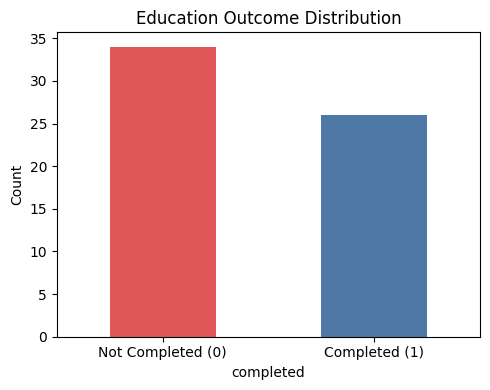

In [7]:
# Target distribution
fig, ax = plt.subplots(figsize=(5, 4))
df["completed"].value_counts().plot(kind="bar", ax=ax, color=["#e15759", "#4e79a7"])
ax.set_xticklabels(["Not Completed (0)", "Completed (1)"], rotation=0)
ax.set_title("Education Outcome Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

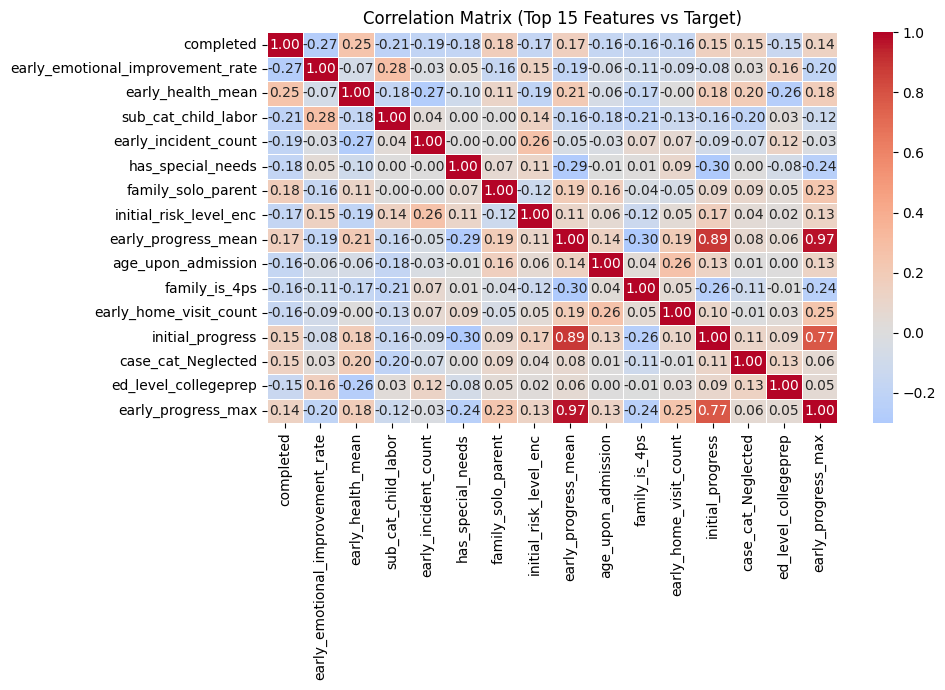


Top 10 features by correlation with completed:
early_emotional_improvement_rate   -0.268649
early_health_mean                   0.253396
sub_cat_child_labor                -0.210580
early_incident_count               -0.189106
has_special_needs                  -0.179379
family_solo_parent                  0.178501
initial_risk_level_enc             -0.173898
early_progress_mean                 0.166324
age_upon_admission                 -0.164509
family_is_4ps                      -0.161477
Name: completed, dtype: float64


In [8]:
# Correlation heatmap — top features correlated with target
numeric_df = df.apply(pd.to_numeric, errors="coerce")
target_corr = (
    numeric_df.corr()["completed"]
    .drop("completed")
    .sort_values(key=abs, ascending=False)
)
top_features = target_corr.dropna().head(15).index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df[["completed"] + top_features].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5,
)
plt.title("Correlation Matrix (Top 15 Features vs Target)")
plt.tight_layout()
plt.show()

print("\nTop 10 features by correlation with completed:")
print(target_corr.head(10))

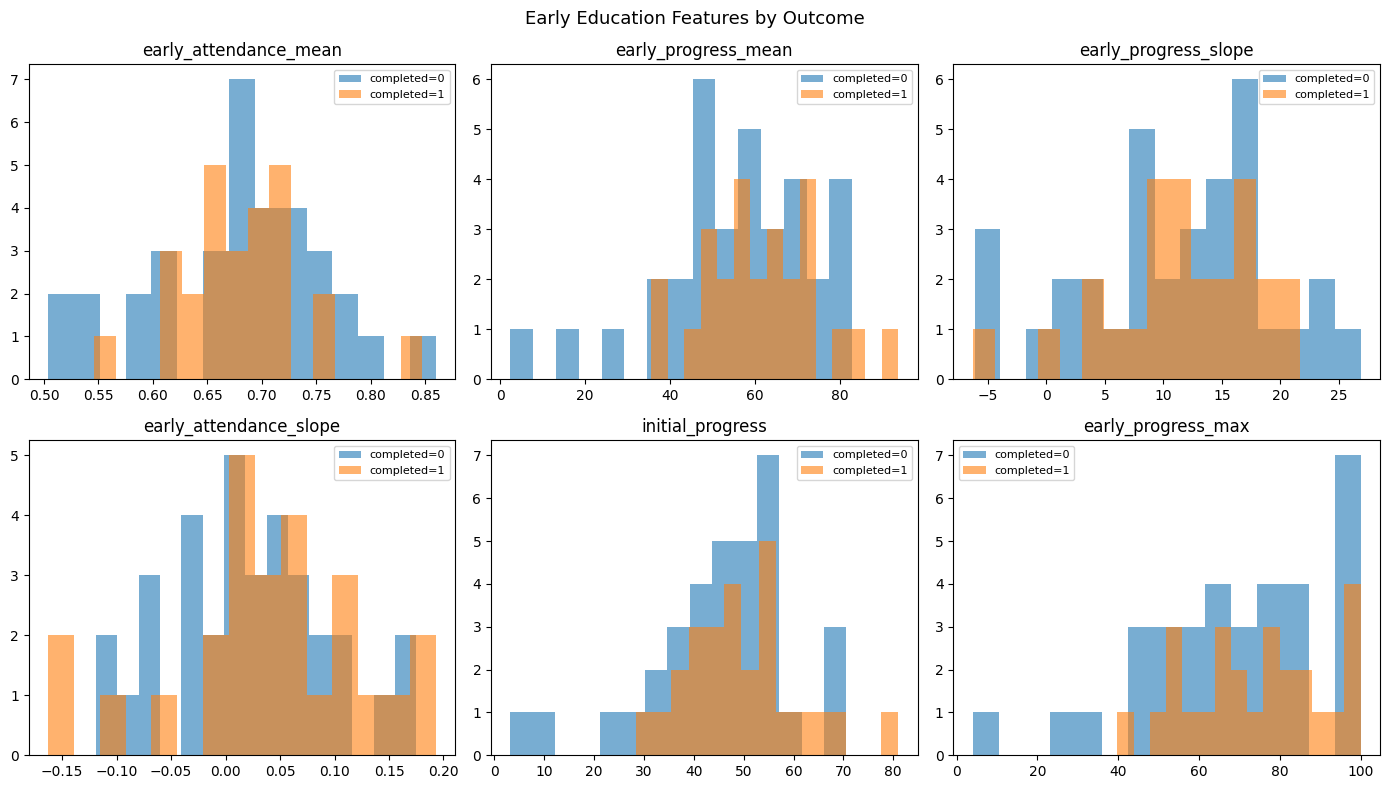

In [9]:
# Distribution of key early education features by outcome
early_feats = [
    "early_attendance_mean", "early_progress_mean",
    "early_progress_slope", "early_attendance_slope",
    "initial_progress", "early_progress_max",
]
early_feats = [f for f in early_feats if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), early_feats):
    for label, grp in df.groupby("completed"):
        ax.hist(grp[feat].dropna(), bins=15, alpha=0.6, label=f"completed={label}")
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle("Early Education Features by Outcome", fontsize=13)
plt.tight_layout()
plt.show()

### EDA Findings and Modeling Decisions

**1. Class balance is workable.**
With 26 completed (~43%) and 34 not completed (~57%), this is a
near-balanced classification problem. We still use
class_weight='balanced' as a precaution, but weighted F1 is the
appropriate primary metric rather than recall (unlike the risk
pipeline where class imbalance was severe).

**2. Early progress features show the clearest separation.**
The distribution plots show that early_progress_mean and
early_progress_slope differ most visibly between completed and
not-completed residents. Residents who complete show higher and
rising early progress scores. This confirms that the prospective
feature window design is capturing meaningful signal — the first
3 months of education records do contain predictive information.

**3. Attendance and progress are correlated.**
The correlation heatmap shows attendance and progress features
are moderately correlated. This means SelectFromModel may drop
one of them during feature selection — this is expected and
acceptable. We do not force both into the model.

**4. Cross-table features may add noise.**
Health scores, session counts, and incident counts are included
but their correlation with the target is lower than the core
education features. The feature selector will determine whether
they contribute. If they are dropped, this tells us that early
education behavior (not broader case factors) is the primary
predictor of completion.

**5. Modeling approach justified by EDA.**
Near-balanced classes and a clear primary signal from progress
features support using weighted F1 as the primary metric.
StratifiedKFold(k=5) is used instead of a holdout set because
n=60 is too small for a reliable fixed split, per Ch. 15
guidance on small-sample evaluation.

---

# 5. Train/Test Split

With only 60 residents, a holdout set is too small to be reliable. We use
**5-fold Stratified CV** with `cross_val_predict` throughout so every resident
gets an out-of-fold prediction. The final model is re-fitted on all 60 residents.

In [ ]:
X = df.drop(columns=["completed"])
y = df["completed"]

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")
print(f"Positive rate: {y.mean():.1%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verify CV fold balance
print("\nCV fold class distributions:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    y_val = y.iloc[val_idx]
    print(f"  Fold {fold}: n={len(val_idx)}, pos={y_val.sum()}, rate={y_val.mean():.0%}")

---

# 6. Baselines and Logistic Regression

In [ ]:
def make_pipeline(model, selector_threshold="mean"):
    """Leakage-safe pipeline for the full feature set."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectFromModel(
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=N_JOBS,
            ),
            threshold=selector_threshold,
        )),
        ("model", model),
    ])


def make_reduced_logistic_pipeline():
    """Simple, interpretable logistic model for the explicit reduced feature set."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42,
        )),
    ])


def build_metric_row(model_name, y_true, y_pred, y_score=None):
    """Return a compact, class-1-focused metric row."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    row = {
        "Model": model_name,
        "Accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "Class 1 Precision": round(float(report["1"]["precision"]), 4),
        "Class 1 Recall": round(float(report["1"]["recall"]), 4),
        "Class 1 F1": round(float(report["1"]["f1-score"]), 4),
        "Weighted F1": round(float(report["weighted avg"]["f1-score"]), 4),
        "ROC-AUC": round(float(roc_auc_score(y_true, y_score)), 4) if y_score is not None else np.nan,
    }
    return row


def oof_proba_and_preds(estimator, X_data, y_data, cv, threshold=0.5):
    """Get out-of-fold probabilities and thresholded predictions."""
    y_proba = cross_val_predict(estimator, X_data, y_data, cv=cv, method="predict_proba")[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return y_proba, y_pred


reduced_feature_list = [
    "early_health_mean",
    "early_attendance_mean",
    "early_progress_mean",
    "early_emotional_improvement_rate",
    "early_attendance_slope",
    "initial_progress",
]

lr_pipe = make_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
)

print("Evaluation helper functions loaded.")
print(f"Reduced logistic feature subset: {reduced_feature_list}")

In [ ]:
# Majority-class baseline: predict every resident as not completed.
majority_clf = DummyClassifier(strategy="most_frequent")
majority_oof_preds = cross_val_predict(majority_clf, X, y, cv=cv, method="predict")
majority_oof_proba = cross_val_predict(majority_clf, X, y, cv=cv, method="predict_proba")[:, 1]
majority_metrics = build_metric_row(
    "Majority Baseline (predict all 0)",
    y,
    majority_oof_preds,
    majority_oof_proba,
)

# Full-feature logistic regression.
lr_oof_proba, lr_oof_preds = oof_proba_and_preds(lr_pipe, X, y, cv=cv, threshold=0.5)
lr_metrics = build_metric_row(
    "Logistic Regression (full features, 0.5 threshold)",
    y,
    lr_oof_preds,
    lr_oof_proba,
)

# Explicit reduced-feature logistic regression.
X_reduced = X[reduced_feature_list].copy()
reduced_lr_pipe = make_reduced_logistic_pipeline()
reduced_lr_oof_proba, reduced_lr_oof_preds = oof_proba_and_preds(
    reduced_lr_pipe,
    X_reduced,
    y,
    cv=cv,
    threshold=0.5,
)
reduced_lr_metrics = build_metric_row(
    "Logistic Regression (reduced features, 0.5 threshold)",
    y,
    reduced_lr_oof_preds,
    reduced_lr_oof_proba,
)

default_logistic_compare_df = pd.DataFrame([
    majority_metrics,
    lr_metrics,
    reduced_lr_metrics,
]).set_index("Model")

print("Default-threshold comparison (majority baseline vs logistic models):")
print(default_logistic_compare_df.to_string())
print("\nInterpretation:")
print("The majority baseline can look decent on accuracy because class 0 is slightly larger,")
print("but it is useless for detecting completed=1 because its class-1 recall and F1 are zero.")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, title in zip(
    axes,
    [majority_oof_preds, lr_oof_preds, reduced_lr_oof_preds],
    [
        "Majority Baseline",
        "Logistic Regression (full)",
        "Logistic Regression (reduced)",
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y,
        preds,
        display_labels=["Not Completed", "Completed"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(title)

plt.suptitle("Confusion Matrices ? Baseline vs Logistic Models", fontsize=13)
plt.tight_layout()
plt.show()

## 6b. Threshold Tuning for Logistic Regression

With a small dataset, the probability threshold should reflect the business tradeoff.
Lower thresholds usually catch more true completions (higher class-1 recall) but create
more false positives. Higher thresholds are stricter and usually improve accuracy while
missing more true completions. We choose the threshold using **out-of-fold logistic
probabilities only**, so no future information leaks into the decision rule.

In [ ]:
threshold_rows = []
for threshold in [0.3, 0.4, 0.5, 0.6]:
    threshold_preds = (lr_oof_proba >= threshold).astype(int)
    row = build_metric_row(
        f"Logistic Regression (full features, threshold={threshold:.1f})",
        y,
        threshold_preds,
        lr_oof_proba,
    )
    row["Threshold"] = threshold
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
threshold_df = threshold_df[[
    "Threshold",
    "Accuracy",
    "Class 1 Precision",
    "Class 1 Recall",
    "Class 1 F1",
    "Weighted F1",
    "ROC-AUC",
]]

best_threshold_row = threshold_df.sort_values(
    ["Class 1 F1", "Class 1 Recall", "Accuracy"],
    ascending=[False, False, False],
).iloc[0]
best_lr_threshold = float(best_threshold_row["Threshold"])
best_lr_threshold_preds = (lr_oof_proba >= best_lr_threshold).astype(int)
best_lr_threshold_metrics = build_metric_row(
    f"Logistic Regression (full features, threshold={best_lr_threshold:.1f})",
    y,
    best_lr_threshold_preds,
    lr_oof_proba,
)

print("Threshold tuning table for full-feature Logistic Regression:")
print(threshold_df.to_string(index=False))
print("\nSelected threshold:")
print(
    f"threshold={best_lr_threshold:.1f} because it maximizes class-1 F1 "
    f"({best_lr_threshold_metrics['Class 1 F1']:.4f}) on out-of-fold predictions."
)
print("This favors catching more completed cases over raw accuracy.")

---

# 7. Advanced Model (Random Forest)

In [ ]:
rf_pipe = make_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=N_JOBS,
    )
)

rf_oof_proba, rf_oof_preds = oof_proba_and_preds(rf_pipe, X, y, cv=cv, threshold=0.5)
rf_metrics = build_metric_row("Random Forest (default)", y, rf_oof_preds, rf_oof_proba)

print("Random Forest (default) ? 5-fold out-of-fold metrics")
print(pd.Series(rf_metrics).to_string())

In [ ]:
# Keep a single tuned Random Forest for comparison only.
# We do not treat it as the recommended model because the simpler logistic
# models are easier to explain and currently perform better on class-1 detection.
param_grid = {
    "selector__threshold": ["mean", "0.5*mean"],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 3],
    "model__max_features": ["sqrt", "log2"],
}

grid_pipe = make_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=N_JOBS)
)

grid_search = GridSearchCV(
    grid_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=N_JOBS,
    verbose=1,
)
grid_search.fit(X, y)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV weighted F1: {grid_search.best_score_:.4f}")

In [ ]:
best_pipe = grid_search.best_estimator_
tuned_oof_proba, tuned_oof_preds = oof_proba_and_preds(best_pipe, X, y, cv=cv, threshold=0.5)
tuned_rf_metrics = build_metric_row("Random Forest (tuned)", y, tuned_oof_preds, tuned_oof_proba)

print("Tuned Random Forest ? 5-fold out-of-fold metrics")
print(pd.Series(tuned_rf_metrics).to_string())

---

# 8. Evaluation and Comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, preds, title in zip(
    axes,
    [majority_oof_preds, reduced_lr_oof_preds, best_lr_threshold_preds, tuned_oof_preds],
    [
        "Majority Baseline",
        "Reduced Logistic (0.5 threshold)",
        f"Full Logistic ({best_lr_threshold:.1f} threshold)",
        "Tuned Random Forest",
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y,
        preds,
        display_labels=["Not Completed", "Completed"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(title)

plt.suptitle("Confusion Matrices ? Practical Comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
comparison_rows = [
    majority_metrics,
    lr_metrics,
    reduced_lr_metrics,
    best_lr_threshold_metrics,
    rf_metrics,
    tuned_rf_metrics,
]

results_df = pd.DataFrame(comparison_rows).set_index("Model")
results_df["Beats Baseline Accuracy"] = results_df["Accuracy"] > majority_metrics["Accuracy"]
results_df["Beats Baseline Class 1 F1"] = results_df["Class 1 F1"] > majority_metrics["Class 1 F1"]

print("Model comparison table:")
print(results_df.to_string())

best_default_logistic_metrics = max(
    [lr_metrics, reduced_lr_metrics],
    key=lambda row: (row["Class 1 F1"], row["ROC-AUC"], row["Accuracy"]),
)

if (
    best_default_logistic_metrics["Accuracy"] > majority_metrics["Accuracy"]
    and best_default_logistic_metrics["Class 1 F1"] >= 0.55
):
    honest_assessment = "promising but weak"
elif best_default_logistic_metrics["Class 1 F1"] > 0:
    honest_assessment = "some signal, but not useful yet"
else:
    honest_assessment = "not useful yet"

print("\nBest default-threshold logistic model:")
print(pd.Series(best_default_logistic_metrics).to_string())
print(f"\nCurrent honest assessment: {honest_assessment}")

### Reduced-Feature Logistic Experiment

The full feature set may be too noisy for a sample this small. To test whether a
simpler model generalizes better, we run a second Logistic Regression using only the
strongest features from the current Random Forest importance ranking. The subset is kept
**explicit in code** so the experiment is reproducible and easy to audit.

In [ ]:
reduced_feature_compare_df = pd.DataFrame([
    lr_metrics,
    reduced_lr_metrics,
]).set_index("Model")

print("Reduced feature subset used in the simpler logistic model:")
for feature in reduced_feature_list:
    print(f"  - {feature}")

print("\nFull vs reduced Logistic Regression:")
print(reduced_feature_compare_df.to_string())

if reduced_lr_metrics["Class 1 F1"] > lr_metrics["Class 1 F1"]:
    print("\nTrimming the feature set helps here: the reduced model improves class-1 detection and overall accuracy.")
else:
    print("\nTrimming the feature set does not help on this run; keep the full feature set if interpretability is not the priority.")

---

# 9. Feature Importance

In [ ]:
# Fit the best pipeline on all data to extract feature importances.
# This is for interpretation only — evaluation was already done via CV.
best_pipe.fit(X, y)

# Extract selected feature names via the selector mask
selector = best_pipe.named_steps["selector"]

all_feature_names = np.array(X.columns)
selected_mask     = selector.get_support()
selected_features = all_feature_names[selected_mask]

print(f"Features in:       {len(all_feature_names)}")
print(f"Features selected: {len(selected_features)}")
print(f"Selected: {list(selected_features)}")

In [ ]:
# Feature importances from the final RF model
rf_model    = best_pipe.named_steps["model"]
importances = rf_model.feature_importances_

importance_df = (
    pd.Series(importances, index=selected_features)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
importance_df[::-1].plot(kind="barh", ax=ax, color="#4e79a7")
ax.set_title("Top Feature Importances — Tuned Random Forest")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10))

---

### Interpretation and Limitations

Most of the usable signal appears to sit in a small set of early education and wellbeing
features: health, attendance, progress, and emotional improvement. That is operationally
useful because those signals are available early enough to support intervention.

The evidence is still weak. This notebook only has 60 residents and 26 completed cases,
so metrics and coefficients can move a lot as new cases arrive. The model is suitable for
flagging residents for human review, not for automated high-stakes decisions.

---

# 10. Save Model

In [ ]:
import pathlib

SAVE_DIR = pathlib.Path("../../saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

recommended_model = make_reduced_logistic_pipeline()
recommended_model.fit(X_reduced, y)

model_path = SAVE_DIR / "education_outcome_model.pkl"
joblib.dump(recommended_model, model_path)
print(f"Model saved to {model_path}")
print("Saved model: Logistic Regression (reduced feature set)")
print(f"Saved feature subset: {reduced_feature_list}")
print("Recommended decision threshold for this saved model: 0.5")

In [ ]:
metadata = {
    "pipeline": "education_outcome",
    "target": "completed",
    "recommended_model_type": "LogisticRegression (reduced feature set)",
    "recommended_threshold": 0.5,
    "recommended_features": reduced_feature_list,
    "best_default_logistic": best_default_logistic_metrics,
    "best_thresholded_logistic": best_lr_threshold_metrics,
    "majority_baseline": majority_metrics,
    "random_forest_default": rf_metrics,
    "random_forest_tuned": tuned_rf_metrics,
    "rf_best_params": grid_search.best_params_,
    "comparison_rows": results_df.reset_index().to_dict(orient="records"),
    "n_residents": int(len(y)),
    "positive_rate": round(float(y.mean()), 4),
    "feature_window_months": 3,
    "n_input_features": int(X.shape[1]),
    "reduced_feature_count": int(len(reduced_feature_list)),
    "leakage_prevention": (
        "prospective feature window (first 3 education records) + "
        "SelectFromModel inside sklearn Pipeline for the full model comparison"
    ),
    "cv_strategy": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "primary_metric": "class_1_f1",
    "supporting_metrics": ["roc_auc", "weighted_f1", "accuracy"],
    "honest_assessment": honest_assessment,
}

meta_path = SAVE_DIR / "education_outcome_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {meta_path}")
print(json.dumps(metadata, indent=2))

---

# 11. Final Honest Summary

In [ ]:
summary_rows = [
    {
        "Summary Item": "Best baseline result",
        "Model": majority_metrics["Model"],
        "Accuracy": majority_metrics["Accuracy"],
        "Class 1 F1": majority_metrics["Class 1 F1"],
        "ROC-AUC": majority_metrics["ROC-AUC"],
    },
    {
        "Summary Item": "Best logistic result",
        "Model": best_default_logistic_metrics["Model"],
        "Accuracy": best_default_logistic_metrics["Accuracy"],
        "Class 1 F1": best_default_logistic_metrics["Class 1 F1"],
        "ROC-AUC": best_default_logistic_metrics["ROC-AUC"],
    },
    {
        "Summary Item": "Best thresholded logistic result",
        "Model": best_lr_threshold_metrics["Model"],
        "Accuracy": best_lr_threshold_metrics["Accuracy"],
        "Class 1 F1": best_lr_threshold_metrics["Class 1 F1"],
        "ROC-AUC": best_lr_threshold_metrics["ROC-AUC"],
    },
]
summary_df = pd.DataFrame(summary_rows).set_index("Summary Item")
print(summary_df.to_string())

if (
    best_default_logistic_metrics["Accuracy"] > majority_metrics["Accuracy"]
    and best_default_logistic_metrics["Class 1 F1"] > majority_metrics["Class 1 F1"]
):
    baseline_message = "Yes ? the recommended logistic model beats the majority baseline in a meaningful way."
else:
    baseline_message = "No ? the logistic model does not beat the majority baseline in a meaningful way yet."

print("\nDoes the pipeline beat baseline meaningfully?")
print(baseline_message)
print("\nHonest interpretation:")
print(honest_assessment)
print(
    "Use this model as an early-review aid, not as an automated decision rule. "
    "The reduced logistic model is the most practical current option because it is simpler, "
    "more interpretable, and stronger than the Random Forest results on this dataset."
)

## 12. Causal and Relationship Analysis

This pipeline is **predictive-first** (early warning for completion risk), with a secondary explanatory lens from logistic coefficients and feature ranking.

### Relationship findings
- Early attendance, early progress, and early health/engagement indicators are the strongest recurring predictors of completion probability.
- Directionally, these relationships are consistent with education and case-management theory: sustained early participation tends to precede better completion outcomes.
- Slope features (early trajectory) provide additional structure beyond static averages and help identify momentum effects.

### Causal caution
- Coefficients and importances should be interpreted as conditional associations, not direct treatment effects.
- Program assignment differences, staff intensity, and resident background factors can confound observed links.
- Strong causal claims would require intervention studies or robust causal inference methods (for example propensity approaches or instrumental strategies).

## 13. Deployment Notes

This notebook persists its trained pipeline to `ml_pipelines/saved_models/education_outcome_model.pkl` with metadata in `ml_pipelines/saved_models/education_outcome_metadata.json`.

Integration points in the repo:
- API loading and endpoint: `ml_pipelines/api/main.py` (`/predict/education-outcome`).
- Frontend ML client call: `frontend/intex/src/services/mlApi.ts` (`predictEducationOutcome`).
- UI usage in reports/analytics flow: `frontend/intex/src/pages/admin/ReportsPage.tsx`.

Deployed behavior: users submit early-window education features from the app, the API returns completion probability, and staff use that score to triage support intensity.